# Retail Sales Data – Exploratory Data Analysis

## Objective

The objective of this project is to perform Exploratory Data Analysis (EDA) on an e-commerce sales dataset to identify sales trends, customer behavior patterns, product performance, and actionable business insights.

The analysis includes data inspection and cleaning, descriptive statistics, time-series analysis, customer demographic analysis, product analysis, correlation analysis, and additional business-oriented visualizations.

## Technology Stack

* Python
* Pandas
* Matplotlib
* Seaborn
* Jupyter Notebook


In [6]:
import sys
print(sys.executable)

C:\Python313\python.exe


In [7]:
import sys
!{sys.executable} -m pip install matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.3 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.3 MB 1.4 MB/s eta 0:00:06
   ---- ----------------------------------- 1.0/9.3 MB 1.5 MB/s eta 0:00:06
   ---- ----------------------------------- 1.0/9.3 MB 1.5 MB/s eta 0:00:06
   ---- ----------------------------------- 1.0/9.3 MB 1.5 MB/s eta 0:00:06
   ------ --------------------------------- 1.6/9.3 MB 1.1 MB/s eta 0:00:08
   ------- -------------------------------- 1.8/9.3 MB 1.1 MB/s eta 0:00:07
   -------- ------------------------------- 2.1/9.3 MB 1.2 MB/s eta 0:00:06
   -------- ------------------------------- 2

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: C:\Python313\python.exe -m pip install --upgrade pip


In [8]:
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

print(matplotlib.__version__)

3.11.1


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")

In [7]:
import pandas as pd

In [5]:
df = pd.read_csv(r"D:\Internship\P1\Level 1\EDA Retail Sales\realistic_e_commerce_sales_data.csv")

In [6]:
df.head()

,Customer ID,Gender,Region,Age,Product Name,Category,Unit Price,Quantity,Total Price,Shipping Fee,Shipping Status,Order Date
0,CUST0268,Male,North,NaN,Monitor,Electronics,300.0,5,1500,13.31,Returned,2023-12-08
1,CUST0046,Male,West,22.0,Headphones,Accessories,100.0,2,200,6.93,In Transit,2023-04-09
2,CUST0169,Female,South,54.0,Monitor,Electronics,300.0,1,300,11.31,Returned,2023-08-28
3,CUST0002,Male,North,23.0,Headphones,Accessories,100.0,5,500,12.22,Delivered,2023-01-18
4,CUST0173,Female,South,NaN,Laptop,Electronics,1500.0,3,4500,5.40,Delivered,2023-01-19


## Dataset Description

The dataset contains 1,000 e-commerce transaction records and 12 original columns covering customer demographics, product information, pricing, shipping details, and order dates.

The main variables used in the analysis include:

- Customer ID – Unique customer identifier
- Gender – Customer gender
- Region – Customer region
- Age – Customer age
- Product Name – Product purchased
- Category – Product category
- Unit Price – Price per unit
- Quantity – Number of units purchased
- Total Price – Total transaction value
- Shipping Fee – Shipping cost
- Shipping Status – Delivery status
- Order Date – Date of the transaction

In [10]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 1000
Number of columns: 12


In [11]:
df.columns

Index(['Customer ID', 'Gender', 'Region', 'Age', 'Product Name', 'Category',
       'Unit Price', 'Quantity', 'Total Price', 'Shipping Fee',
       'Shipping Status', 'Order Date'],
      dtype='str')

In [12]:
df.dtypes

Customer ID            str
Gender                 str
Region                 str
Age                float64
Product Name           str
Category               str
Unit Price         float64
Quantity             int64
Total Price          int64
Shipping Fee       float64
Shipping Status        str
Order Date             str
dtype: object

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Customer ID      1000 non-null   str    
 1   Gender           1000 non-null   str    
 2   Region           950 non-null    str    
 3   Age              900 non-null    float64
 4   Product Name     1000 non-null   str    
 5   Category         1000 non-null   str    
 6   Unit Price       1000 non-null   float64
 7   Quantity         1000 non-null   int64  
 8   Total Price      1000 non-null   int64  
 9   Shipping Fee     1000 non-null   float64
 10  Shipping Status  950 non-null    str    
 11  Order Date       1000 non-null   str    
dtypes: float64(3), int64(2), str(7)
memory usage: 93.9 KB


In [13]:
df.isnull().sum()

Customer ID          0
Gender               0
Region              50
Age                100
Product Name         0
Category             0
Unit Price           0
Quantity             0
Total Price          0
Shipping Fee         0
Shipping Status     50
Order Date           0
dtype: int64

In [24]:
missing_summary = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Missing Percentage': (df.isnull().sum() / len(df)) * 100
})

missing_summary

,Missing Values,Missing Percentage
Customer ID,0,0.0
Gender,0,0.0
Region,50,5.0
Age,100,10.0
Product Name,0,0.0
Category,0,0.0
Unit Price,0,0.0
Quantity,0,0.0
Total Price,0,0.0
Shipping Fee,0,0.0


In [26]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.describe()

,Age,Unit Price,Quantity,Total Price,Shipping Fee
count,900.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,46.695556,457.703777,3.008000,1346.600000,12.416390
std,15.011400,537.231434,1.404246,1834.037877,4.412185
min,18.000000,30.000000,1.000000,30.000000,5.000000
25%,35.000000,50.000000,2.000000,200.000000,8.560000
50%,49.000000,200.000000,3.000000,600.000000,12.315000
75%,59.000000,800.000000,4.000000,1500.000000,16.075000
max,69.000000,3109.560612,5.000000,7500.000000,19.980000


## Initial Data Inspection – Observation

The dataset contains 1,000 records and 12 columns covering customer information, product details, transaction values, shipping information, and order dates.

The initial inspection was performed using the dataset shape, column names, data types, dataset information, missing-value counts, duplicate checks, and descriptive statistics.

The `Order Date` column requires conversion to a proper datetime format before performing time-series analysis. Missing values identified during the inspection will be handled during the data-cleaning stage.


In [28]:
print("Region values:")
print(df['Region'].value_counts(dropna=False))

print("\nShipping Status values:")
print(df['Shipping Status'].value_counts(dropna=False))

Region values:
Region
West     246
South    244
East     231
North    229
NaN       50
Name: count, dtype: int64

Shipping Status values:
Shipping Status
In Transit    329
Delivered     313
Returned      308
NaN            50
Name: count, dtype: int64


In [29]:
df['Age'].describe()

count    900.000000
mean      46.695556
std       15.011400
min       18.000000
25%       35.000000
50%       49.000000
75%       59.000000
max       69.000000
Name: Age, dtype: float64

In [31]:
df['Age'].isnull().sum()

np.int64(100)

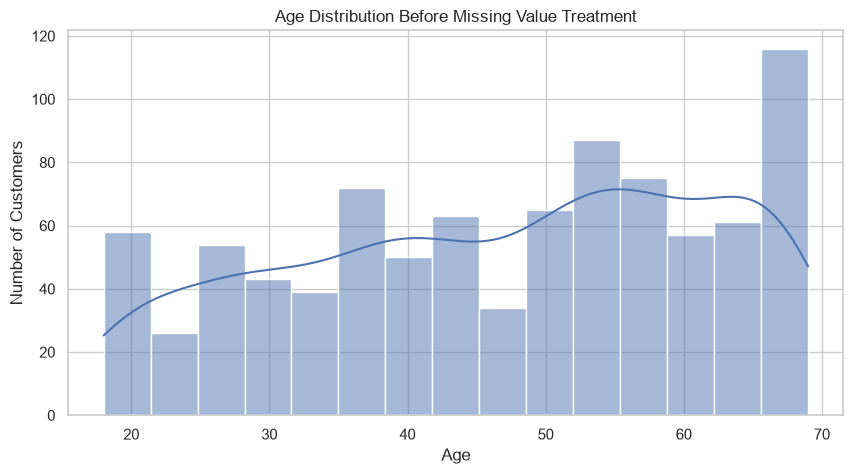

In [17]:
plt.figure(figsize=(10, 5))

sns.histplot(df['Age'].dropna(), bins=15, kde=True)

plt.title('Age Distribution Before Missing Value Treatment')
plt.xlabel('Age')
plt.ylabel('Number of Customers')

plt.show()

### Observation – Age Distribution

The customer ages range from 18 to 69 years, showing that the dataset contains customers across a broad adult age range. The distribution is relatively spread out, with a noticeable concentration among customers in the higher age ranges.

This indicates that the business serves customers from different age groups rather than being limited to a very narrow demographic. Age-based segmentation can therefore be useful for understanding differences in purchasing behavior.


In [6]:
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [7]:
df.dtypes

Customer ID                   str
Gender                        str
Region                        str
Age                       float64
Product Name                  str
Category                      str
Unit Price                float64
Quantity                    int64
Total Price                 int64
Shipping Fee              float64
Shipping Status               str
Order Date         datetime64[us]
Month                         str
dtype: object

In [21]:
print("Minimum Order Date:",df['Order Date'].min())
print("Maximum Order Date:",df['Order Date'].max())

Minimum Order Date: 2023-01-01 00:00:00
Maximum Order Date: 2024-01-03 00:00:00


In [22]:
print("Minimum Unit Price:",df['Unit Price'].min())
print("Minimum Quantity:",df['Quantity'].min())
print("Minimum Total Price:",df['Total Price'].min())
print("Minimun Shipping Fee:",df['Shipping Fee'].min())

Minimum Unit Price: 30.0
Minimum Quantity: 1
Minimum Total Price: 30
Minimun Shipping Fee: 5.0


In [23]:
df['Calculated Total'] = df['Unit Price'] * df['Quantity']

In [24]:
df['Price Difference'] = (
    df['Total Price'] - df['Calculated Total']
)

df['Price Difference'].describe()

count    1000.000000
mean      -32.191212
std       372.084929
min     -8047.803062
25%         0.000000
50%         0.000000
75%         0.000000
max         0.000000
Name: Price Difference, dtype: float64

In [25]:
df[df['Price Difference'] != 0].head()

,Customer ID,Gender,Region,Age,Product Name,Category,Unit Price,Quantity,Total Price,Shipping Fee,Shipping Status,Order Date,Calculated Total,Price Difference
26,CUST0264,Male,East,59.0,Smartphone,Electronics,1658.432327,2,1600,11.59,In Transit,2023-02-01,3316.864653,-1716.864653
83,CUST0219,Male,NaN,48.0,Mouse,Accessories,62.191212,2,60,7.40,Returned,2023-08-20,124.382424,-64.382424
84,CUST0037,Male,West,51.0,Keyboard,Accessories,103.652020,4,200,11.41,Returned,2023-05-20,414.608082,-214.608082
110,CUST0223,Female,NaN,20.0,Mouse,Accessories,62.191212,2,60,15.12,In Transit,2023-05-26,124.382424,-64.382424
194,CUST0269,Male,North,64.0,Monitor,Electronics,621.912122,5,1500,6.93,Delivered,2023-04-23,3109.560612,-1609.560612


In [26]:
mismatched_rows = df[df['Price Difference'] != 0]

print("Number of mismatched rows:", len(mismatched_rows))
print("Percentage of mismatched rows:", 
      len(mismatched_rows) / len(df) * 100)

Number of mismatched rows: 20
Percentage of mismatched rows: 2.0


In [27]:
mismatched_rows[['Unit Price', 'Quantity', 'Total Price',
                 'Calculated Total', 'Price Difference']].head(20)

,Unit Price,Quantity,Total Price,Calculated Total,Price Difference
26,1658.432327,2,1600,3316.864653,-1716.864653
83,62.191212,2,60,124.382424,-64.382424
84,103.652020,4,200,414.608082,-214.608082
110,62.191212,2,60,124.382424,-64.382424
194,621.912122,5,1500,3109.560612,-1609.560612
209,621.912122,5,1500,3109.560612,-1609.560612
215,62.191212,1,30,62.191212,-32.191212
226,103.652020,4,200,414.608082,-214.608082
244,621.912122,3,900,1865.736367,-965.736367
339,207.304041,1,100,207.304041,-107.304041


In [34]:
mismatched_rows.sort_values('Price Difference').head(10)

,Customer ID,Gender,Region,Age,Product Name,Category,Unit Price,Quantity,Total Price,Shipping Fee,Shipping Status,Order Date,Calculated Total,Price Difference
560,CUST0204,Male,West,54.0,Laptop,Electronics,3109.560612,5,7500,19.71,Returned,2023-04-18,15547.803062,-8047.803062
967,CUST0131,Female,North,67.0,Laptop,Electronics,3109.560612,4,6000,18.27,NaN,2023-08-26,12438.242450,-6438.242450
756,CUST0138,Female,West,46.0,Laptop,Electronics,3109.560612,2,3000,6.44,Delivered,2023-12-08,6219.121225,-3219.121225
374,CUST0178,Female,South,44.0,Smartphone,Electronics,1658.432327,3,2400,19.31,Delivered,2023-06-03,4975.296980,-2575.296980
421,CUST0011,Female,West,54.0,Smartphone,Electronics,1658.432327,2,1600,15.80,In Transit,2023-04-06,3316.864653,-1716.864653
26,CUST0264,Male,East,59.0,Smartphone,Electronics,1658.432327,2,1600,11.59,In Transit,2023-02-01,3316.864653,-1716.864653
702,CUST0064,Male,West,61.0,Laptop,Electronics,3109.560612,1,1500,18.37,In Transit,2023-09-01,3109.560612,-1609.560612
209,CUST0134,Male,North,NaN,Monitor,Electronics,621.912122,5,1500,7.22,Returned,2023-08-05,3109.560612,-1609.560612
194,CUST0269,Male,North,64.0,Monitor,Electronics,621.912122,5,1500,6.93,Delivered,2023-04-23,3109.560612,-1609.560612
244,CUST0128,Female,North,52.0,Monitor,Electronics,621.912122,3,900,11.04,Delivered,2023-10-25,1865.736367,-965.736367


In [35]:
mismatched_rows['Price Difference'].describe()

count      20.000000
mean    -1609.560612
std      2146.371647
min     -8047.803062
25%     -1716.864653
50%      -965.736367
75%      -201.195077
max       -32.191212
Name: Price Difference, dtype: float64

In [31]:
mismatched_rows['Category'].value_counts()

Category
Electronics    12
Accessories     8
Name: count, dtype: int64

In [33]:
mismatched_rows['Product Name'].value_counts()

Product Name
Monitor       5
Mouse         4
Laptop        4
Smartphone    3
Keyboard      2
Headphones    2
Name: count, dtype: int64

In [36]:
df['Region'] = df['Region'].fillna('Unknown')

In [43]:
df['Shipping Status'] = df['Shipping Status'].fillna('Unknown')


In [57]:
median_age = df['Age'].median()
print(median_age)

49.0


In [64]:
df['Age'] = df['Age'].replace('Unknown', np.nan)
df['Age'] = pd.to_numeric(df['Age'])

median_age = df['Age'].median()
df['Age'] = df['Age'].fillna(median_age)

In [46]:
df.isnull().sum()

Customer ID         0
Gender              0
Region              0
Age                 0
Product Name        0
Category            0
Unit Price          0
Quantity            0
Total Price         0
Shipping Fee        0
Shipping Status     0
Order Date          0
Calculated Total    0
Price Difference    0
dtype: int64

In [47]:
df.drop(
    columns=['Calculated Total', 'Price Difference'],
    inplace=True
)

In [51]:
df.dtypes

Customer ID                   str
Gender                        str
Region                        str
Age                       float64
Product Name                  str
Category                      str
Unit Price                float64
Quantity                    int64
Total Price                 int64
Shipping Fee              float64
Shipping Status               str
Order Date         datetime64[us]
dtype: object

In [52]:
df.shape

(1000, 12)

## Data Cleaning Summary

The dataset was checked for missing values, incorrect data types, duplicate records, and numerical inconsistencies.

The missing values in the `Region` and `Shipping Status` columns were replaced with `Unknown` because the actual categories could not be determined from the available data.

The 100 missing values in the `Age` column were replaced using the median age of 49 after examining the age distribution. Median imputation was selected because it is less sensitive to extreme values than the mean.

The `Order Date` column was converted from a string/object type to a datetime type to enable monthly, quarterly, and yearly time-series analysis.

A consistency check was also performed by comparing `Total Price` with `Unit Price × Quantity`. Only 20 records, representing 2% of the dataset, showed discrepancies. The original `Total Price` values were retained rather than overwriting them because the differences may represent pricing adjustments or discounts, and changing the source values would introduce an unsupported assumption.


In [20]:
numeric_cols = df.select_dtypes(include=np.number).columns

print(numeric_cols)

Index(['Age', 'Unit Price', 'Quantity', 'Total Price', 'Shipping Fee'], dtype='str')


In [69]:
df[numeric_cols].dtypes

Age             float64
Unit Price      float64
Quantity          int64
Total Price       int64
Shipping Fee    float64
dtype: object

In [70]:
stats = pd.DataFrame({
    'Mean': df[numeric_cols].mean(),
    'Median': df[numeric_cols].median(),
    'Mode': df[numeric_cols].mode().iloc[0],
    'Standard Deviation': df[numeric_cols].std()
})

stats

,Mean,Median,Mode,Standard Deviation
Age,46.926000,49.000,49.00,14.257061
Unit Price,457.703777,200.000,300.00,537.231434
Quantity,3.008000,3.000,3.00,1.404246
Total Price,1346.600000,600.000,200.00,1834.037877
Shipping Fee,12.416390,12.315,9.26,4.412185


In [71]:
df[numeric_cols].describe()

,Age,Unit Price,Quantity,Total Price,Shipping Fee
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,46.926000,457.703777,3.008000,1346.600000,12.416390
std,14.257061,537.231434,1.404246,1834.037877,4.412185
min,18.000000,30.000000,1.000000,30.000000,5.000000
25%,37.000000,50.000000,2.000000,200.000000,8.560000
50%,49.000000,200.000000,3.000000,600.000000,12.315000
75%,58.000000,800.000000,4.000000,1500.000000,16.075000
max,69.000000,3109.560612,5.000000,7500.000000,19.980000


## Descriptive Statistics – Observation

The descriptive statistics provide an overview of customer demographics, pricing, purchasing quantity, transaction value, and shipping fees.

The average customer age is approximately 46.93 years, while the median age is 49 years. Customer ages range from 18 to 69 years, indicating a broad customer base.

The average unit price is 457.70, which is considerably higher than the median price of 200. This difference suggests that some higher-priced products increase the overall average.

The average quantity purchased per transaction is approximately 3 units, with the mean, median, and mode all being close to 3. This indicates that customers typically purchase around three units per transaction.

Total Price shows a substantial difference between its mean of 1,346.60 and median of 600, along with a high standard deviation of 1,834.04. This indicates considerable variation in transaction values and suggests the presence of some high-value transactions.

Shipping fees have a mean of approximately 12.42 and a median of 12.315, indicating that shipping costs are relatively concentrated around this range.


## Time Series Analysis

Time-series analysis is used to understand how sales change over time. In this section, monthly and quarterly sales will be analyzed using the `Order Date` and `Total Price` columns.

The analysis will help identify periods of higher and lower sales and can provide insights for sales planning, inventory management, and promotional activities.


In [72]:
df['Month'] = df['Order Date'].dt.to_period('M')

In [73]:
df[['Order Date','Month']].head()

,Order Date,Month
0,2023-12-08,2023-12
1,2023-04-09,2023-04
2,2023-08-28,2023-08
3,2023-01-18,2023-01
4,2023-01-19,2023-01


In [74]:
monthly_sales = df.groupby('Month')['Total Price'].sum()

monthly_sales

Month
2023-01    141360
2023-02     78910
2023-03     67660
2023-04     87840
2023-05    120080
2023-06    129450
2023-07    103160
2023-08    108050
2023-09    119490
2023-10    118240
2023-11    147150
2023-12    113830
2024-01     11380
Freq: M, Name: Total Price, dtype: int64

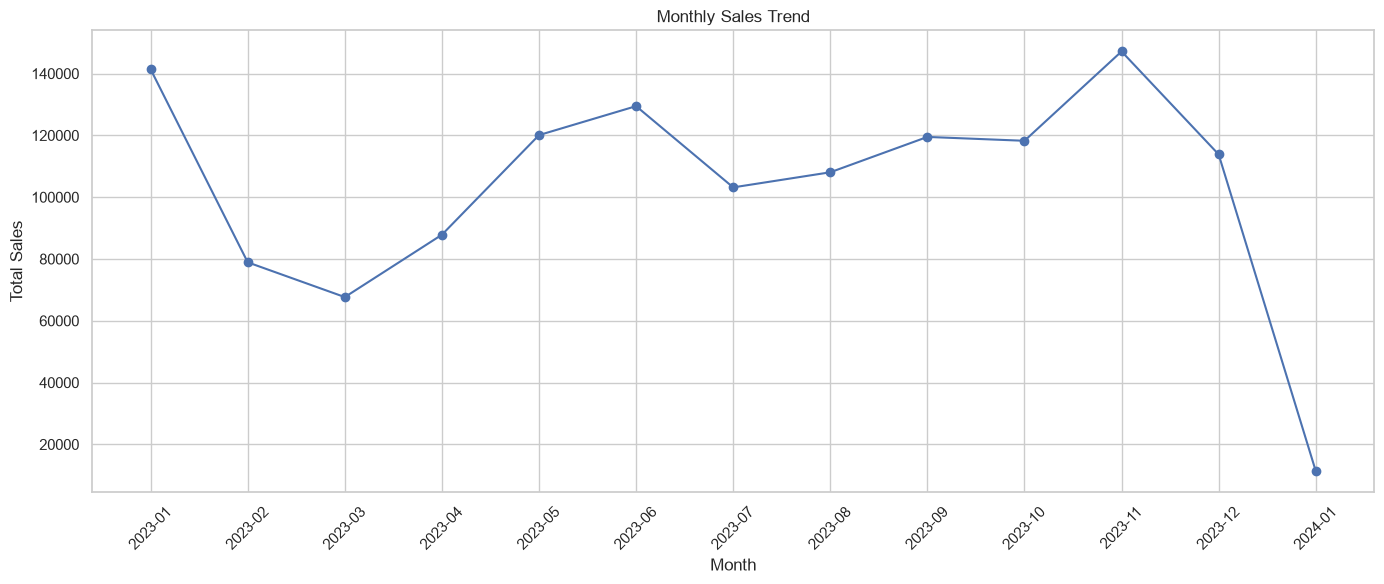

In [75]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values,
    marker='o'
)

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


## Observation – Monthly Sales Trend

The monthly sales trend shows considerable variation throughout the period. Sales declined from approximately 141,000 in January 2023 to around 68,000 in March 2023, which was the lowest sales level among the complete months.

Sales then recovered from April onwards, reaching approximately 120,000 in May and 129,000 in June. After a decline in July, sales remained relatively stable between August and October before reaching the highest level of approximately 147,000 in November 2023.

Sales declined again in December to approximately 114,000. January 2024 shows substantially lower sales; however, this should not be interpreted as a significant decline because the dataset only contains records through January 3, 2024, making it a partial month.

Overall, the analysis indicates fluctuations in monthly demand, with November showing the strongest sales performance. The business can use these trends to plan inventory and promotional campaigns around high-demand periods.

In [7]:
df.to_csv(
    r"D:\Internship\P1\Level 1\EDA Retail Sales\cleaned_ecommerce_sales_data.csv",
    index=False
)

In [8]:
df = pd.read_csv(r"D:\Internship\P1\Level 1\EDA Retail Sales\cleaned_ecommerce_sales_data.csv")

In [8]:
df['Quarter'] = df['Order Date'].dt.to_period('Q')

In [9]:
df[['Order Date','Quarter']].head()

,Order Date,Quarter
0,2023-12-08,2023Q4
1,2023-04-09,2023Q2
2,2023-08-28,2023Q3
3,2023-01-18,2023Q1
4,2023-01-19,2023Q1


In [10]:
quarterly_sales = df.groupby('Quarter')['Total Price'].sum()

quarterly_sales

Quarter
2023Q1    287930
2023Q2    337370
2023Q3    330700
2023Q4    379220
2024Q1     11380
Freq: Q-DEC, Name: Total Price, dtype: int64

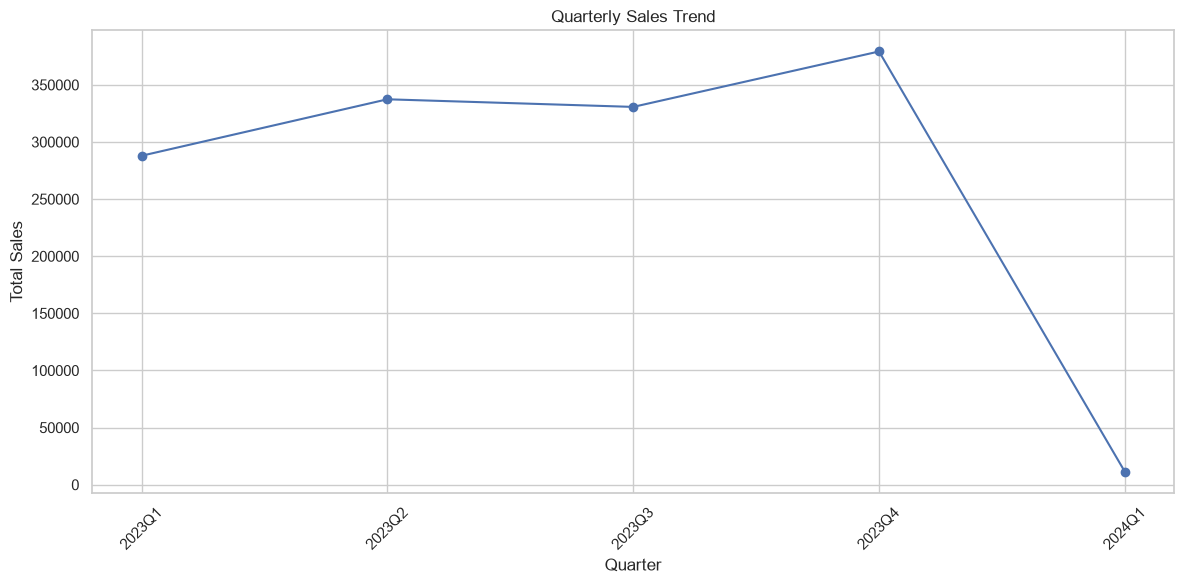

In [13]:
plt.figure(figsize=(12, 6))

plt.plot(
    quarterly_sales.index.astype(str),
    quarterly_sales.values,
    marker='o'
)

plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Observation – Quarterly Sales Trend

The quarterly sales trend shows an overall improvement in sales during 2023. Sales increased from approximately 287,000 in Q1 2023 to around 337,000 in Q2 2023, followed by a slight decline to approximately 329,000 in Q3.

Sales reached the highest level in Q4 2023, at approximately 380,000. This indicates that the fourth quarter was the strongest sales period in the available complete quarters.

Q1 2024 shows very low sales compared with the previous quarters; however, this should not be interpreted as a decline in quarterly performance because the dataset contains records only through January 3, 2024. Therefore, Q1 2024 represents only a partial quarter.

The results suggest that the business experienced stronger sales toward the end of 2023, which could be useful for planning inventory, staffing, and promotional activities during high-demand periods.


In [9]:
df.to_csv(r"D:\Internship\P1\Level 1\EDA Retail Sales\cleaned_ecommerce_sales_data_v2.csv", index=False)

In [10]:
df = pd.read_csv(r"D:\Internship\P1\Level 1\EDA Retail Sales\cleaned_ecommerce_sales_data_v2.csv")

## Customer Demographics Analysis

Customer demographic analysis helps identify the types of customers represented in the dataset. Age and gender distributions are analyzed to understand the major customer segments and support targeted marketing and customer strategies.


In [5]:
bins = [17, 30, 40, 50, 60, 70]

labels = [
    '18-30',
    '31-40',
    '41-50',
    '51-60',
    '61-70'
]

df['Age Group'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels
)

In [6]:
df['Age Group'].value_counts().sort_index()

Age Group
18-30    177
31-40    140
41-50    263
51-60    214
61-70    206
Name: count, dtype: int64

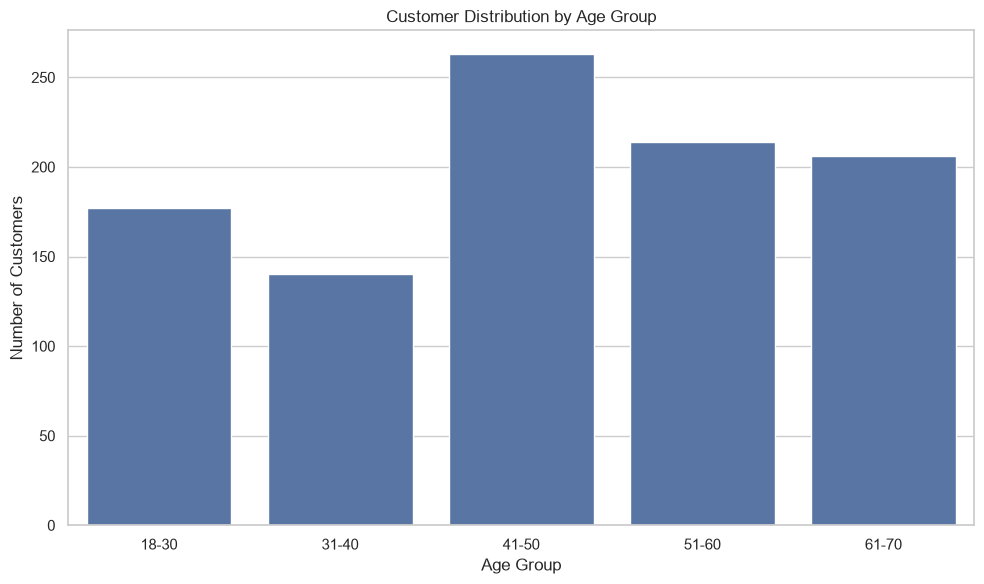

In [7]:
age_group_counts = df['Age Group'].value_counts().sort_index()

plt.figure(figsize=(10, 6))

sns.barplot(
    x=age_group_counts.index,
    y=age_group_counts.values
)

plt.title('Customer Distribution by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

### Observation – Customer Age Groups

The age-group analysis shows that customers are distributed across all five age groups. The **41–50 age group has the highest representation**, indicating that middle-aged customers form an important segment of the customer base.

The **31–40 age group has the lowest representation**, while the 18–30, 51–60, and 61–70 groups also contribute a significant number of customers.

This distribution indicates that the business serves a relatively broad age range. Marketing strategies can therefore be tailored to different age segments rather than focusing on a single customer group.


In [9]:
gender_counts = df['Gender'].value_counts()

gender_counts

Gender
Male      524
Female    476
Name: count, dtype: int64

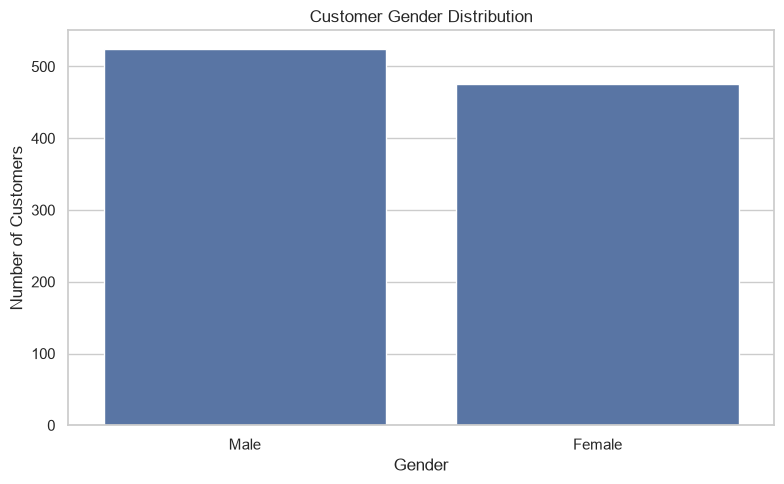

In [10]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=gender_counts.index,
    y=gender_counts.values
)

plt.title('Customer Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

### Observation – Gender Distribution

The gender distribution shows that the customer base is relatively balanced between male and female customers. Male customers represent a slightly larger share of the dataset than female customers.

The relatively balanced distribution suggests that the business has a broad customer base and should consider maintaining marketing strategies that appeal to both customer segments rather than relying heavily on a single gender.


## Product Analysis

Product-level analysis helps identify which products contribute most to sales volume and which product categories generate the highest revenue.

In this section, the top 10 best-selling products will be identified based on quantity sold, followed by an analysis of revenue generated by each product category.


In [11]:
top_products = (
    df.groupby('Product Name')['Quantity']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products

Product Name
Monitor       503
Laptop        464
Keyboard      458
Smartphone    442
Mouse         400
Smartwatch    371
Headphones    370
Name: Quantity, dtype: int64

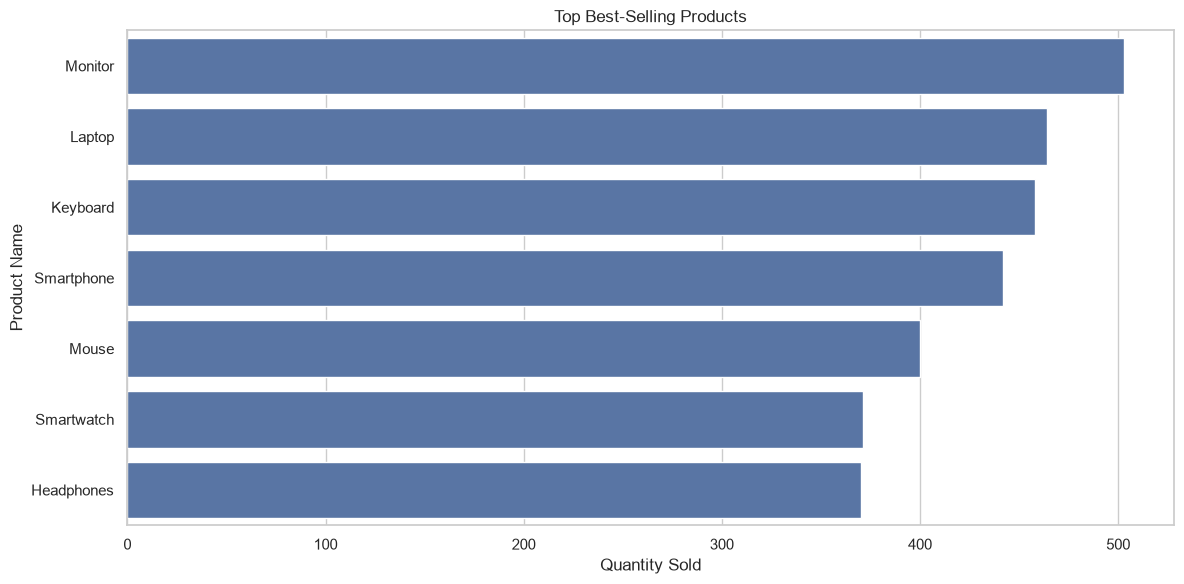

In [14]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title('Top Best-Selling Products')
plt.xlabel('Quantity Sold')
plt.ylabel('Product Name')

plt.tight_layout()
plt.show()

### Observation – Top-Selling Products

The product-level analysis shows differences in sales volume across the available products. **Monitor** has the highest quantity sold, followed by **Laptop** and **Keyboard**, while **Smartwatch** and **Headphones** have the lowest sales volumes among the products in the dataset.

The results indicate that certain products have stronger customer demand and may require greater inventory availability. Lower-volume products could be further analyzed to understand whether pricing, customer preferences, or product positioning is affecting their sales performance.

The dataset contains seven unique products, so the analysis presents all available products rather than artificially adding products to reach ten.


In [15]:
category_revenue = (
    df.groupby('Category')['Total Price']
      .sum()
      .sort_values(ascending=False)
)

category_revenue

Category
Electronics    1200500
Wearables        74200
Accessories      71900
Name: Total Price, dtype: int64

In [17]:
category_revenue_percentage = (
    category_revenue / category_revenue.sum() * 100
)

category_revenue_percentage

Category
Electronics    89.150453
Wearables       5.510174
Accessories     5.339373
Name: Total Price, dtype: float64

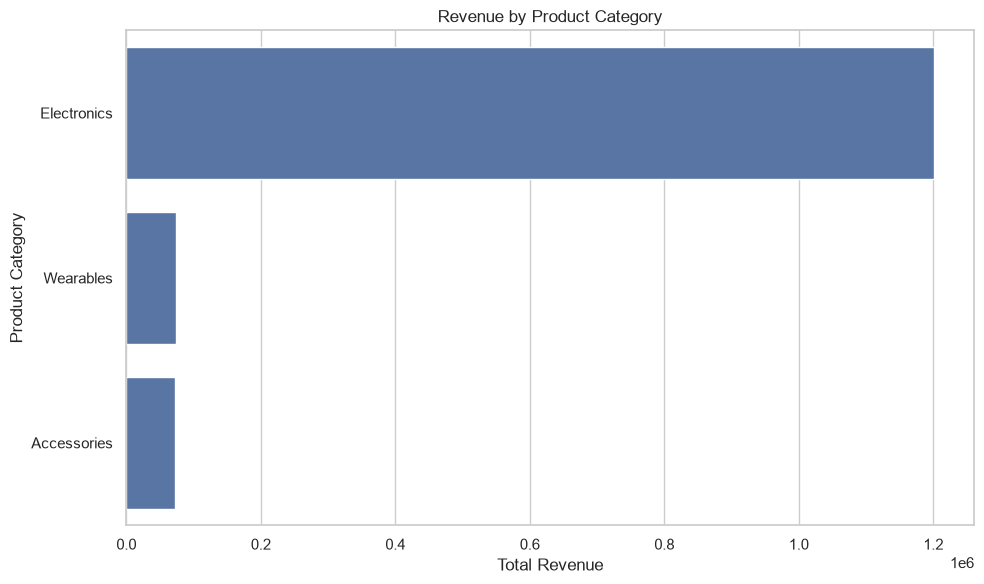

In [16]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=category_revenue.values,
    y=category_revenue.index
)

plt.title('Revenue by Product Category')
plt.xlabel('Total Revenue')
plt.ylabel('Product Category')

plt.tight_layout()
plt.show()

### Observation – Revenue by Product Category

The revenue analysis shows a very large difference in performance across product categories. **Electronics generates the highest revenue by a substantial margin**, while Wearables and Accessories contribute much smaller amounts.

This indicates that the business is heavily dependent on the Electronics category for its overall revenue. The company should continue maintaining strong inventory availability for Electronics while also exploring opportunities to increase revenue from Wearables and Accessories through targeted promotions, product bundles, and cross-selling strategies.

The strong concentration of revenue in Electronics also represents a potential business risk because weaker performance in this category could have a significant impact on overall sales.


## Correlation Analysis

Correlation analysis is used to measure the strength and direction of linear relationships between numerical variables.

A correlation coefficient ranges from -1 to +1:

* **+1** indicates a strong positive relationship.
* **0** indicates little or no linear relationship.
* **-1** indicates a strong negative relationship.

A correlation heatmap is used to visualize these relationships and identify variables that may have meaningful associations.


In [21]:
correlation_matrix = df[numeric_cols].corr()

correlation_matrix

,Age,Unit Price,Quantity,Total Price,Shipping Fee
Age,1.000000,0.054737,0.016479,0.038586,0.024008
Unit Price,0.054737,1.000000,0.002678,0.824360,0.016851
Quantity,0.016479,0.002678,1.000000,0.360877,0.045812
Total Price,0.038586,0.824360,0.360877,1.000000,0.003249
Shipping Fee,0.024008,0.016851,0.045812,0.003249,1.000000


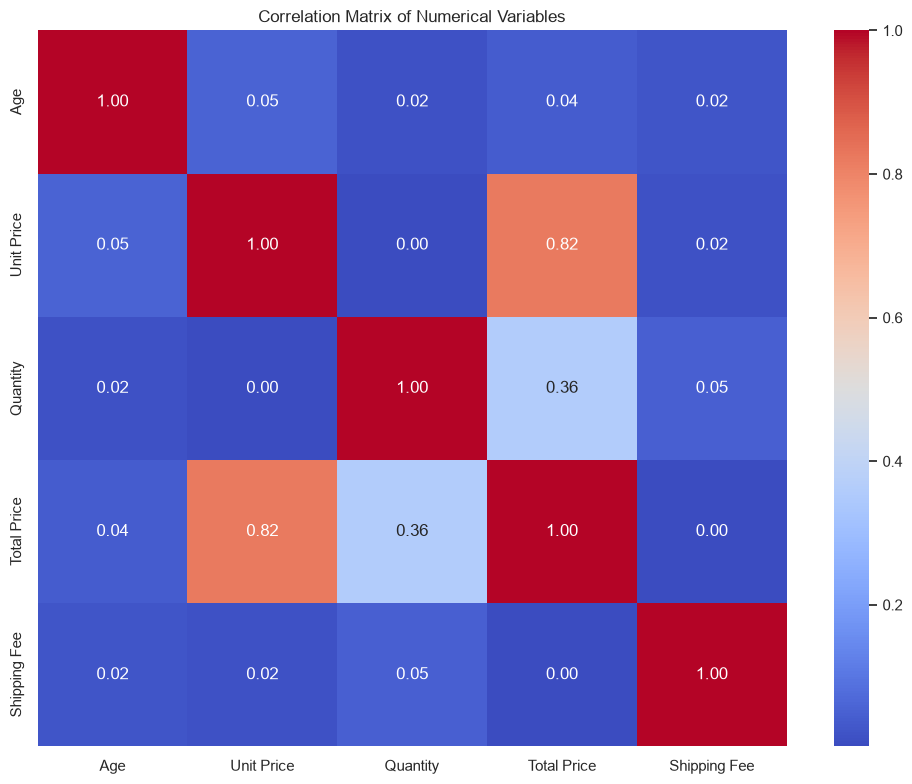

In [22]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix of Numerical Variables')

plt.tight_layout()
plt.show()

### Observation – Correlation Analysis

The correlation analysis shows that **Unit Price and Total Price have the strongest positive relationship, with a correlation coefficient of 0.82**. This indicates that higher-priced products tend to be associated with higher transaction values.

Quantity has a moderate positive correlation with Total Price of approximately 0.36, suggesting that purchasing more units generally contributes to higher transaction values, although the relationship is weaker than that of Unit Price.

Customer Age has very weak correlations with Total Price, Unit Price, and Quantity, with correlation values close to zero. This indicates that age does not have a strong linear relationship with purchasing value in this dataset.

Shipping Fee also has almost no correlation with Total Price. Overall, product pricing appears to be a more important factor associated with transaction value than customer age or shipping fee.

Correlation indicates association rather than causation, so these relationships should not be interpreted as proof that one variable directly causes another.


In [23]:
avg_transaction_age = (
    df.groupby('Age Group', observed=True)['Total Price']
      .mean()
      .sort_values(ascending=False)
)

avg_transaction_age

Age Group
41-50    1443.726236
51-60    1439.485981
61-70    1386.893204
18-30    1234.067797
31-40    1105.142857
Name: Total Price, dtype: float64

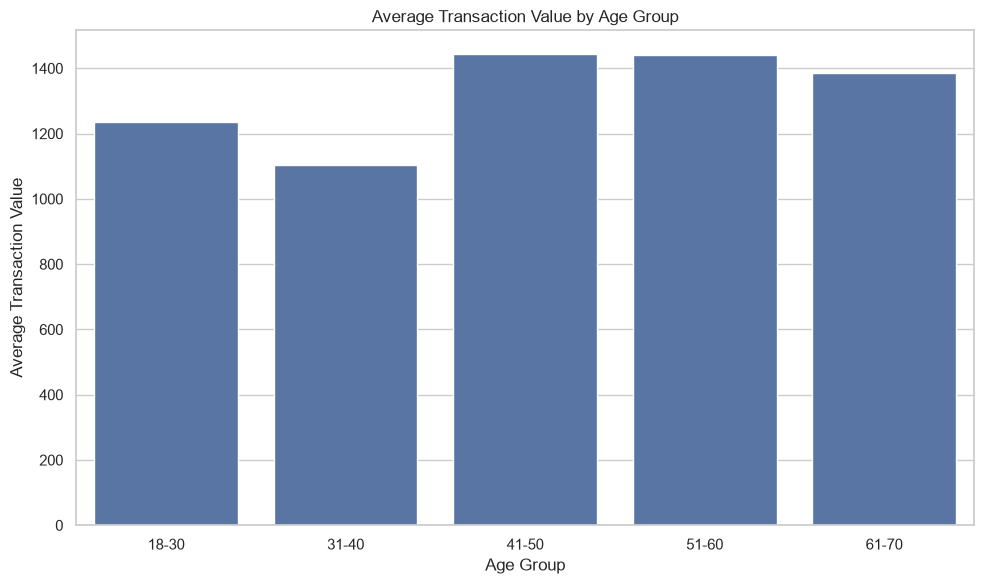

In [24]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=avg_transaction_age.index,
    y=avg_transaction_age.values
)

plt.title('Average Transaction Value by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Average Transaction Value')

plt.tight_layout()
plt.show()

### Observation – Average Transaction Value by Age Group

The analysis reveals an important difference between customer population size and transaction value. Although the **41–50 age group has the largest number of customers**, the **51–60 age group has the highest average transaction value**, with the 41–50 group being very close.

The 61–70 age group also shows a relatively high average transaction value, while the 31–40 age group has the lowest average transaction value among the analyzed segments.

This indicates that customer segments should not be evaluated only based on their population size. Older customer groups may represent valuable segments because they generate relatively higher-value transactions. The business could consider targeted promotions and premium product offerings for these higher-value segments.


In [25]:
total_revenue = df['Total Price'].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 1346600


In [26]:
total_quantity = df['Quantity'].sum()

print("Total Quantity Sold:", total_quantity)

Total Quantity Sold: 3008


In [27]:
average_transaction = df['Total Price'].mean()

print("Average Transaction Value:", average_transaction)

Average Transaction Value: 1346.6


In [28]:
number_of_transactions = df.shape[0]

print("Number of Transactions:", number_of_transactions)

Number of Transactions: 1000


In [29]:
best_product = top_products.idxmax()
best_product_quantity = top_products.max()

print("Best-Selling Product:", best_product)
print("Quantity Sold:", best_product_quantity)

Best-Selling Product: Monitor
Quantity Sold: 503


In [30]:
best_category = category_revenue.idxmax()
best_category_revenue = category_revenue.max()

print("Highest-Revenue Category:", best_category)
print("Revenue:", best_category_revenue)

Highest-Revenue Category: Electronics
Revenue: 1200500


In [31]:
kpi_summary = pd.DataFrame({
    'KPI': [
        'Total Revenue',
        'Total Quantity Sold',
        'Number of Transactions',
        'Average Transaction Value',
        'Best-Selling Product',
        'Highest-Revenue Category'
    ],
    'Value': [
        total_revenue,
        total_quantity,
        number_of_transactions,
        average_transaction,
        best_product,
        best_category
    ]
})

kpi_summary

,KPI,Value
0,Total Revenue,1346600
1,Total Quantity Sold,3008
2,Number of Transactions,1000
3,Average Transaction Value,1346.6
4,Best-Selling Product,Monitor
5,Highest-Revenue Category,Electronics


# Key Insights

Based on the EDA, the major findings are:

1. November 2023 recorded the highest monthly sales.
2. Q4 2023 recorded the highest sales among the complete quarters.
3. The 41–50 age group has the largest customer representation.
4. The 41–50 age group has the highest average transaction value.
5. Monitor is the best-selling product by quantity.
6. Electronics generates the majority of total revenue.
7. Unit Price has a strong positive correlation of approximately 0.82 with Total Price.
8. Only 2% of transactions showed discrepancies between Unit Price × Quantity and Total Price.

# Business Recommendations

Based on the exploratory analysis, the following recommendations can be made:

### 1. Prioritize Electronics inventory and availability

Electronics generates the majority of total revenue, making it the most important product category for the business. The company should maintain adequate inventory levels for high-demand Electronics products, particularly products such as Monitors, Laptops, and Smartphones, to reduce the risk of stockouts.

### 2. Target high-value customer segments

The 41–50 age group has the highest average transaction value, while the 51–60 group also demonstrates relatively high transaction values. The business could develop targeted promotions, premium product recommendations, and personalized offers for these higher-value customer segments.

### 3. Use seasonal sales patterns for planning

Q4 2023 recorded the highest sales among the complete quarters, while November 2023 was the strongest month. The business should prepare inventory, staffing, and promotional campaigns in advance of historically stronger sales periods.

### 4. Increase sales from lower-performing categories

Electronics significantly outperforms Wearables and Accessories in revenue. The business could use cross-selling and bundle offers, such as combining Electronics products with Accessories or Wearables, to increase sales in the lower-performing categories.

### 5. Investigate lower-value customer segments

The 31–40 age group has the lowest average transaction value. The business could test targeted discounts, product bundles, and personalized recommendations for this segment to increase average transaction value.

### 6. Strengthen transaction-data validation

The consistency check identified discrepancies between `Unit Price × Quantity` and `Total Price` in approximately 2% of transactions. The business should implement validation rules in the sales system to flag unusual pricing differences for review and improve data quality.


# Conclusion

The exploratory analysis of the e-commerce sales dataset provided insights into sales trends, customer demographics, product performance, and transaction behavior.

Sales showed considerable monthly variation during 2023, with November recording the highest monthly sales and Q4 2023 recording the highest sales among the complete quarters. The customer base was distributed across multiple age groups, with the 41–50 group having the largest customer representation. However, the 51–60 group recorded the highest average transaction value, demonstrating that the largest customer segment is not necessarily the highest-value segment.

Product analysis showed that Monitor was the best-selling product by quantity, while Electronics generated substantially more revenue than Wearables and Accessories. The correlation analysis also showed a strong positive relationship between Unit Price and Total Price, with a correlation of approximately 0.82.

Overall, the analysis suggests that the business should prioritize high-performing Electronics products, target higher-value customer segments, plan inventory and promotions around stronger sales periods, and develop strategies to increase revenue from lower-performing categories. The analysis also highlighted a small number of transaction-level pricing inconsistencies that should be monitored to improve data quality.


In [11]:
import os
print(os.path.abspath("Retail Sales Data.ipynb"))

C:\Users\theje\Retail Sales Data.ipynb
